# 1. Dataset Selection:

o Choose a dataset that interests you. Real datasets preferred (e.g., not
Kaggle/UCI repository). Provide a brief description of the dataset, including
its source, size, and key features.

I obtained these datasets through: [Data.gov](https://data.gov/).

[Lottery Powerball Winning Numbers](https://catalog.data.gov/dataset/lottery-powerball-winning-numbers-beginning-2010) (767.MB):Powerball wining numbers in the state of New York (2010-present). 

[Fireball & Bolide Reports](https://catalog.data.gov/dataset/fireball-and-bolide-reports) (6.2KB)): Fireballs and bolides are astronomical terms for exceptionally bright meteors that are spectacular enough to to be seen over a very wide area. The following table provides a chronological data summary of fireball and bolide events provided by U.S. Government sensors. Ground-based observers sometimes also witness these events at night, or much more rarely in daylight, as impressive atmospheric light displays. This website is not meant to be a complete list of all fireball events. Only the brightest fireballs are noted.

[Trips by Distance](https://catalog.data.gov/dataset/trips-by-distance) (796.7MB) : The Trips by Distance data and number of people staying home and not staying home are estimated for the Bureau of Transportation Statistics by the Maryland Transportation Institute and Center for Advanced Transportation Technology Laboratory at the University of Maryland. The travel statistics are produced from an anonymized national panel of mobile device data from multiple sources. All data sources used in the creation of the metrics contain no personal information. Data analysis is conducted at the aggregate national, state, and county levels. A weighting procedure expands the sample of millions of mobile devices, so the results are representative of the entire population in a nation, state, or county. To assure confidentiality and support data quality, no data are reported for a county if it has fewer than 50 devices in the sample on any given day.Trips are defined as movements that include a stay of longer than 10 minutes at an anonymized location away from home. Home locations are imputed on a weekly basis. A movement with multiple stays of longer than 10 minutes before returning home is counted as multiple trips. Trips capture travel by all modes of transportation. including driving, rail, transit, and air.

[Crash Case Information](https://catalog.data.gov/dataset/motor-vehicle-crashes-case-information-three-year-window) (350.5MB) : 2019-2021 crash information in the state of new york.  

I wanted to investgate if there were any patterns for when the powerball winning numbers were annouced and how it correlated/had any pattern to the trips people took, crashes, and even fireball/meteor citings. (These winning numbers are from the city of New York)

In [224]:
import pandas as pd

#import the csv files as dataframes

OGtrips_df = pd.read_csv("Daily_Mobility_Statistics.csv")
OGfireball_df = pd.read_csv("Fireball_And_Bolide_Reports_rows.csv")
OGpowerball_df = pd.read_csv("Lottery_Powerball_Winning_Numbers__Beginning_2010.csv")
OGcrash_df = pd.read_csv("Motor_Vehicle_Crashes_-_Case_Information__Three_Year_Window.csv")

# 2. Data Cleaning and Preparation:

o Conduct exploratory data analysis (EDA) to understand the dataset’s
structure and quality.

o Identify and handle missing values, outliers, and any inconsistencies.

o Transform and encode categorical features as necessary.

In [225]:
#put them in a dictionary so it's easier to analyize all at once. 

dfs = {
    "Powerball": OGpowerball_df,
    "Crashs": OGcrash_df,
    "Fireballs": OGfireball_df,
    "Trips": OGtrips_df
}

In [226]:
#use a for loop to print all the descriptives of the data in the dfs

for name, df in dfs.items():
    print("-" * 100)    #nice little border
    print(name)
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    print("Data types:")
    print(df.dtypes.value_counts())

----------------------------------------------------------------------------------------------------
Powerball
Shape: (1871, 3)
Columns:
['Draw Date', 'Winning Numbers', 'Multiplier']
Data types:
object     2
float64    1
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Crashs
Shape: (1918715, 18)
Columns:
['Year', 'Crash Descriptor', 'Time', 'Date', 'Day of Week', 'Police Report', 'Lighting Conditions', 'Municipality', 'Collision Type Descriptor', 'County Name', 'Road Descriptor', 'Weather Conditions', 'Traffic Control Device', 'Road Surface Conditions', 'DOT Reference Marker Location', 'Pedestrian Bicyclist Action', 'Event Descriptor', 'Number of Vehicles Involved']
Data types:
object    16
int64      2
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Fireballs
Shape: (92, 10)
Columns:
['Date/Time - Peak Brightness (UT)', 'Latitud

In [227]:
#now to actually see the dfs just just a for loop to print them all since I chose 4

for name, df in dfs.items():
    print(name)
    display(df.head(3))

Powerball


,Draw Date,Winning Numbers,Multiplier
0,09/26/2020,11 21 27 36 62 24,3.0
1,09/30/2020,14 18 36 49 67 18,2.0
2,10/03/2020,18 31 36 43 47 20,2.0


Crashs


,Year,Crash Descriptor,Time,Date,Day of Week,Police Report,Lighting Conditions,Municipality,Collision Type Descriptor,County Name,Road Descriptor,Weather Conditions,Traffic Control Device,Road Surface Conditions,DOT Reference Marker Location,Pedestrian Bicyclist Action,Event Descriptor,Number of Vehicles Involved
0,2019,Property Damage Accident,3:00,01/01/2019,Tuesday,Y,Dark-Road Unlighted,CHILI,OTHER,MONROE,Curve and Level,Rain,NaN,Wet,NaN,Not Applicable,"Fence, Collision With Fixed Object",1
1,2019,Property Damage Accident,20:57,01/01/2019,Tuesday,Y,Dark-Road Unlighted,PITTSFORD,OTHER,MONROE,Straight and Level,Clear,NaN,Dry,NaN,Not Applicable,Deer,1
2,2019,Injury Accident,13:20,02/03/2019,Sunday,Y,Daylight,QUEENS,OTHER,QUEENS,Straight and Level,Clear,NaN,Dry,NaN,Not Applicable,"Other Motor Vehicle, Collision With",3


Fireballs


,Date/Time - Peak Brightness (UT),Latitude (Deg),Longitude (Deg),Altitude (km),Velocity (km/s),Velocity Components (km/s): vx,Velocity Components (km/s): vy,Velocity Components (km/s): vz,Total Radiated Energy (J),Calculated Total Impact Energy (kt)
0,11/21/2009 08:53:00 PM,22.0S,29.2E,38.0,32.1,3.0,-17.0,-27.0,10000000000000,18.00
1,01/09/2015 10:41:11 AM,2.0N,28.8E,36.0,NaN,-10.7,-7.6,11.6,139000000000,0.41
2,05/16/2014 12:42:48 PM,44.2S,176.2W,44.0,NaN,14.4,4.6,6.5,309000000000,0.82


Trips


,Geographic Level,Date,State FIPS,State Postal Code,County FIPS,County Name,Population Staying at Home,Population Not Staying at Home,Number of Trips,Number of Trips <1,...,Number of Trips 5-10,Number of Trips 10-25,Number of Trips 25-50,Number of Trips 50-100,Number of Trips 100-250,Number of Trips 250-500,Number of Trips >=500,Row ID,Week,Month
0,National,2019/01/01,NaN,NaN,NaN,NaN,77433867.0,248733553.0,8.977844e+08,241667151.0,...,129670778.0,116904343.0,40432062.0,15686639.0,7525563.0,1806022.0,1728112.0,00-00000-20190101,0,1
1,National,2019/01/02,NaN,NaN,NaN,NaN,61305201.0,264862219.0,1.139452e+09,291276735.0,...,171637514.0,167412698.0,56148976.0,17739183.0,7817044.0,1962301.0,1531219.0,00-00000-20190102,0,1
2,National,2019/01/03,NaN,NaN,NaN,NaN,63050480.0,263116940.0,1.162753e+09,296375014.0,...,175775410.0,172027487.0,57632422.0,18366626.0,8124548.0,2038099.0,1567072.0,00-00000-20190103,0,1


In [228]:
#Now to clean up the data, and handpick which columns I want + reassign a cleaned up dictionary dataframe just in case

crash_df = OGcrash_df[
    [
        "Crash Descriptor",
        "Date",
        "Day of Week",
        "Municipality",
        "County Name",
        "Weather Conditions",
        "Number of Vehicles Involved",
        "Event Descriptor",
    ]
].copy()

fireball_df = OGfireball_df[
    [
        "Date/Time - Peak Brightness (UT)", 
        "Latitude (Deg)",
        "Longitude (Deg)",
        "Velocity (km/s)",
        "Total Radiated Energy (J)",
        "Calculated Total Impact Energy (kt)",
    ]
].copy()

# trips_clean
trips_df = OGtrips_df[
    [
        "Date",
        "Geographic Level",
        "State Postal Code",
        "County Name",
        "Population Staying at Home",
        "Population Not Staying at Home",
        "Number of Trips",
        "Number of Trips <1",
        "Number of Trips 1-3",
        "Number of Trips 3-5",
        "Number of Trips 5-10",
        "Number of Trips 10-25",
        "Number of Trips 25-50",
        "Number of Trips 50-100",
        "Number of Trips 100-250",
        "Number of Trips 250-500",
        "Number of Trips >=500",
    ]
].copy()

#notice how I didn't touch the powerball one it's because I wan to utlitze all of the columns

dfs = {
    "Crashs": crash_df,
    "Fireballs": fireball_df,
    "Powerball": OGpowerball_df,
    "Trips": trips_df
}


In [229]:
#now use a for loop to check for missing values 

for name, df in dfs.items():
    print("-" * 100)
    print(name)
    print("Top missing columns:")
    print(df.isna().sum().sort_values(ascending=False).head(10))   #key line in this, organzing if there is missing values, adding it all together then ordering it
    print("Shape:", df.shape)

----------------------------------------------------------------------------------------------------
Crashs
Top missing columns:
Municipality                   10356
Crash Descriptor                   0
Date                               0
Day of Week                        0
County Name                        0
Weather Conditions                 0
Number of Vehicles Involved        0
Event Descriptor                   0
dtype: int64
Shape: (1918715, 8)
----------------------------------------------------------------------------------------------------
Fireballs
Top missing columns:
Velocity (km/s)                        85
Date/Time - Peak Brightness (UT)        0
Latitude (Deg)                          0
Longitude (Deg)                         0
Total Radiated Energy (J)               0
Calculated Total Impact Energy (kt)     0
dtype: int64
Shape: (92, 6)
----------------------------------------------------------------------------------------------------
Powerball
Top missing columns

It seems like muncipality is the top missing value column for crashes but it seems to account for ~1%, i'll drop those entries. For fireball most of the entires are missing velocity so I'll drop the column entirely since I could reply on values of J(total radiated energy and kt(calculated total impact energy). for powerball, it seems that 10% of the entires are missing a multiplier number and I plan to change it to 0 and I'll work under the asummpstion there was no multiplier. Lastly for trips it seems that theres almost an equal value of n/a entires across the trips columns so I'll just drop all those entries since it accounts for ~0.8% of the data & also drop the county name since I can rely on state postal code (I just want to look at the state of New York).

In [230]:
#drop munciplaity for crash
crash_df_clean = crash_df.dropna(subset=["Municipality"]).copy()

#drop velocity for fireball
fireball_df_clean = fireball_df.drop(columns=["Velocity (km/s)"], errors="ignore").copy()


#reassing the powerball df since it still says OG + now replace multiplier n/a's with 0
powerball_df_clean = OGpowerball_df.copy()
powerball_df_clean["Multiplier"] = powerball_df_clean["Multiplier"].fillna(0)

#drop column county name and then drop the n/a values in number of trips 
trips_df_clean = trips_df.drop(columns=["County Name"], errors="ignore").copy()
trips_df_clean = trips_df_clean.dropna(
    subset=[
        "Population Staying at Home",
        "Population Not Staying at Home"
    ]
).copy()

dfs_clean = {
    "Crashs": crash_df_clean,
    "Fireballs": fireball_df_clean,
    "Powerball": powerball_df_clean,
    "Trips": trips_df_clean
}

In [231]:
for name, df in dfs_clean.items():
    print("-" * 100)
    print(name)
    print("Top missing columns:")
    print(df.isna().sum().sort_values(ascending=False).head(10))   #key line in this, organzing if there is missing values, adding it all together then ordering it
    print("Shape:", df.shape)

----------------------------------------------------------------------------------------------------
Crashs
Top missing columns:
Crash Descriptor               0
Date                           0
Day of Week                    0
Municipality                   0
County Name                    0
Weather Conditions             0
Number of Vehicles Involved    0
Event Descriptor               0
dtype: int64
Shape: (1908359, 8)
----------------------------------------------------------------------------------------------------
Fireballs
Top missing columns:
Date/Time - Peak Brightness (UT)       0
Latitude (Deg)                         0
Longitude (Deg)                        0
Total Radiated Energy (J)              0
Calculated Total Impact Energy (kt)    0
dtype: int64
Shape: (92, 5)
----------------------------------------------------------------------------------------------------
Powerball
Top missing columns:
Draw Date          0
Winning Numbers    0
Multiplier         0
dtype: int64
S

In [232]:
#seems like we still have some missing state postal codes so I'll just drop those too since it's still a very small percentage
trips_df_clean = trips_df_clean.dropna(subset=["State Postal Code"]).copy()

print(trips_df_clean.isna().sum().sort_values(ascending=False).head(10))

Date                              0
Geographic Level                  0
State Postal Code                 0
Population Staying at Home        0
Population Not Staying at Home    0
Number of Trips                   0
Number of Trips <1                0
Number of Trips 1-3               0
Number of Trips 3-5               0
Number of Trips 5-10              0
dtype: int64


In [233]:
#Now to do a value counts on all the categorical data columns to make sure there's nothing misspelled/unique
crash_cat_cols = [
    "Crash Descriptor",
    "Day of Week",
    "Municipality",
    "County Name",
    "Weather Conditions",
    "Event Descriptor"
]

for col in crash_cat_cols:
    print(crash_df_clean[col].value_counts())

Crash Descriptor
Property Damage Accident             1363887
Property Damage & Injury Accident     373846
Injury Accident                       165620
Fatal Accident                          5006
Name: count, dtype: int64
Day of Week
Friday       310938
Thursday     285744
Wednesday    285185
Tuesday      281661
Monday       270012
Saturday     255744
Sunday       219075
Name: count, dtype: int64
Municipality
QUEENS           158322
KINGS            153685
BRONX             89339
HEMPSTEAD         82592
NEW YORK          79426
                  ...  
PROSPECT              1
EAST RANDOLPH         1
DERING HARBOR         1
FILLMORE              1
BLOOMINGDALE          1
Name: count, Length: 1299, dtype: int64
County Name
SUFFOLK        191204
NASSAU         186610
QUEENS         158321
KINGS          153685
WESTCHESTER    100936
                ...  
SCHOHARIE        3834
ORLEANS          3272
YATES            3272
SCHUYLER         2656
HAMILTON         1101
Name: count, Length: 62, dty

# 3. Data Analysis and Visualization:

o Perform analysis to derive insights. This may include descriptive statistics,
correlational analysis, and other relevant metrics.

o Create visualizations to eTectively communicate your findings (e.g.,
histograms, scatter plots, box plots, heatmaps).

In [234]:
#Trying to combine the Crash case and trips, I'm going to reduce the trips by distance to only new york (starting), then combine the dataframes
ny_trips = trips_df_clean[trips_df_clean["State Postal Code"] == "NY"].copy()  # Added parentheses here
ny_trips["date_key"] = pd.to_datetime(ny_trips["Date"], errors="coerce").dt.date
ny_trips = ny_trips.dropna(subset=["date_key"]).copy()
crash_ny = crash_df_clean.copy()
crash_ny["date_key"] = pd.to_datetime(crash_ny["Date"], errors="coerce").dt.date
crash_ny = crash_ny.dropna(subset=["date_key"]).copy()

trips_daily_ny = ny_trips.groupby("date_key")["Number of Trips"].sum().reset_index(name="trips_total")

crashes_daily = crash_ny.groupby("date_key").size().reset_index(name="crash_count")

trips_crashes_ny = trips_daily_ny.merge(crashes_daily, on="date_key", how="left")

trips_crashes_ny["crash_count"] = trips_crashes_ny["crash_count"].fillna(0)
trips_crashes_ny

,date_key,trips_total,crash_count
0,2019-01-01,121915900.0,781.0
1,2019-01-02,157068090.0,977.0
2,2019-01-03,158156476.0,1124.0
3,2019-01-04,159820226.0,1263.0
4,2019-01-05,154772592.0,979.0
...,...,...,...
1918,2024-04-02,183895577.0,0.0
1919,2024-04-03,178602715.0,0.0
1920,2024-04-04,179127993.0,0.0
1921,2024-04-05,179673515.0,0.0


In [235]:
# combine trips and powerball now (using date key), clean/group powerball & trips by day, then merge

trips_df_clean = trips_df_clean.copy()
trips_df_clean["date_key"] = pd.to_datetime(trips_df_clean["Date"], errors="coerce").dt.date
trips_df_clean = trips_df_clean.dropna(subset=["date_key"]).copy()

powerball_df_clean = powerball_df_clean.copy()
powerball_df_clean["date_key"] = pd.to_datetime(powerball_df_clean["Draw Date"], errors="coerce").dt.date
powerball_df_clean = powerball_df_clean.dropna(subset=["date_key"]).copy()

powerball_daily = powerball_df_clean.groupby("date_key").size().reset_index(name="powerball_draws")
trips_daily = trips_df_clean.groupby("date_key")["Number of Trips"].sum().reset_index(name="trips_total")

trips_powerball_df = trips_daily.merge(powerball_daily, on="date_key", how="left")
trips_powerball_df["powerball_draws"] = trips_powerball_df["powerball_draws"].fillna(0)

trips_powerball_df

,date_key,trips_total,powerball_draws
0,2019-01-01,1.795544e+09,0.0
1,2019-01-02,2.278869e+09,1.0
2,2019-01-03,2.325469e+09,0.0
3,2019-01-04,2.363873e+09,0.0
4,2019-01-05,2.360912e+09,1.0
...,...,...,...
1918,2024-04-02,2.616992e+09,0.0
1919,2024-04-03,2.518005e+09,1.0
1920,2024-04-04,2.527478e+09,0.0
1921,2024-04-05,2.685791e+09,0.0


In [236]:
#merge the fireball and crash data using date key, and then merge using the crash dates as a key
crash_df_clean = crash_df_clean.copy()
crash_df_clean["date_key"] = pd.to_datetime(crash_df_clean["Date"], errors="coerce").dt.date
crash_df_clean = crash_df_clean.dropna(subset=["date_key"]).copy()

fireball_df_clean = fireball_df_clean.copy()
fireball_df_clean["date_key"] = pd.to_datetime(
    fireball_df_clean["Date/Time - Peak Brightness (UT)"],
    errors="coerce"
).dt.date
fireball_df_clean = fireball_df_clean.dropna(subset=["date_key"]).copy()

crash_daily = crash_df_clean.groupby("date_key").size().reset_index(name="crash_count")
fireball_daily = fireball_df_clean.groupby("date_key").size().reset_index(name="fireball_count")

crash_fireball_df = crash_daily.merge(fireball_daily, on="date_key", how="left")
crash_fireball_df["fireball_count"] = crash_fireball_df["fireball_count"].fillna(0)

crash_fireball_df.sort_values(by="fireball_count", ascending=True)


C:\Users\angel\AppData\Local\Temp\ipykernel_28616\385267602.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fireball_df_clean["date_key"] = pd.to_datetime(


,date_key,crash_count,fireball_count
1823,2023-12-29,997,0.0
1822,2023-12-28,1085,0.0
1821,2023-12-27,1016,0.0
1820,2023-12-26,759,0.0
1819,2023-12-25,538,0.0
...,...,...,...
18,2019-01-19,1273,0.0
17,2019-01-18,1399,0.0
16,2019-01-17,1202,0.0
1825,2023-12-31,614,0.0


In [237]:
#Now to combine NY crashes with powerball since the dates acutally line up: again using date key for both cleaned dfs, combining using crash as the base
crash_df_clean = crash_df_clean.copy()
crash_df_clean["date_key"] = pd.to_datetime(crash_df_clean["Date"], errors="coerce").dt.date
crash_df_clean = crash_df_clean.dropna(subset=["date_key"]).copy()

powerball_df_clean = powerball_df_clean.copy()
powerball_df_clean["date_key"] = pd.to_datetime(powerball_df_clean["Draw Date"], errors="coerce").dt.date
powerball_df_clean = powerball_df_clean.dropna(subset=["date_key"]).copy()

crash_daily = (
    crash_df_clean
    .groupby("date_key")
    .size()
    .reset_index(name="crash_count")
)

powerball_daily = (
    powerball_df_clean
    .groupby("date_key")
    .size()
    .reset_index(name="powerball_draws")
)

crash_powerball_df = crash_daily.merge(
    powerball_daily,
    on="date_key",
    how="left"
)

crash_powerball_df["powerball_draws"] = crash_powerball_df["powerball_draws"].fillna(0)

crash_powerball_df

,date_key,crash_count,powerball_draws
0,2019-01-01,781,0.0
1,2019-01-02,977,1.0
2,2019-01-03,1124,0.0
3,2019-01-04,1263,0.0
4,2019-01-05,979,1.0
...,...,...,...
1821,2023-12-27,1016,1.0
1822,2023-12-28,1085,0.0
1823,2023-12-29,997,0.0
1824,2023-12-30,752,1.0


Seems like the fireball and crash data have nothing in common, this seems to be because the dates don't match up at all, because the crash dates are from 2019-2023 & fireballs from 2009-2015. I'm not going to use this dataframe then. 

Okay so the total mixed dataframes we have by far are:

1. Trips + Crashes (merged date), only NY
2. Trips + Powerball (merged date)
3. Crash + Powerball (merged date)

In [253]:
#I'm going to merge 1, & 3  but limit the trips to NY using what we already created & fill in the missing values
ny_trips_crash_powerball_df = trips_crashes_ny.merge(
    crash_powerball_df[["date_key", "powerball_draws"]],
    on="date_key",
    how="left"
)
ny_trips_crash_powerball_df["powerball_draws"] = ny_trips_crash_powerball_df["powerball_draws"].fillna(0)

ny_trips_crash_powerball_df

,date_key,trips_total,crash_count,powerball_draws
0,2019-01-01,121915900.0,781.0,0.0
1,2019-01-02,157068090.0,977.0,1.0
2,2019-01-03,158156476.0,1124.0,0.0
3,2019-01-04,159820226.0,1263.0,0.0
4,2019-01-05,154772592.0,979.0,1.0
...,...,...,...,...
1918,2024-04-02,183895577.0,0.0,0.0
1919,2024-04-03,178602715.0,0.0,0.0
1920,2024-04-04,179127993.0,0.0,0.0
1921,2024-04-05,179673515.0,0.0,0.0


Okay so the total mixed dataframes we have are:

1. Trips + Crashes (merged date), only NY
2. Trips + Powerball (merged date)
3. Crash + Powerball (merged date)
4. Crash + trips + Powerball (merged dates), only NY for trips

For Anaylsis:

1. look at daily trips and crash counts in New York and check how they relate using summary statistics, correlation, and a scatter plot.
2. Plot trips and crashes over time to see how travel and crash patterns change across the years.
3. Compare trips on Powerball draw days and non draw days using summary statistics and box plots.
4. Compare crash counts on Powerball draw days and non draw days and check if draw days behave differently.

In [308]:
import matplotlib.pyplot as plt

#descriptive statistics for 1

tc = trips_crashes_ny.copy()
tc["date_key"] = pd.to_datetime(tc["date_key"])

tc[["trips_total", "crash_count"]].describe()

,trips_total,crash_count
count,1.923000e+03,1923.000000
mean,1.754115e+08,992.386375
std,2.622762e+07,325.571958
min,7.466879e+07,0.000000
25%,1.604573e+08,880.000000
50%,1.800306e+08,1025.000000
75%,1.945621e+08,1170.000000
max,2.319835e+08,2500.000000


In [281]:
#corelation table between the two 
tc[["trips_total", "crash_count"]].corr()

,trips_total,crash_count
trips_total,1.000000,0.243225
crash_count,0.243225,1.000000


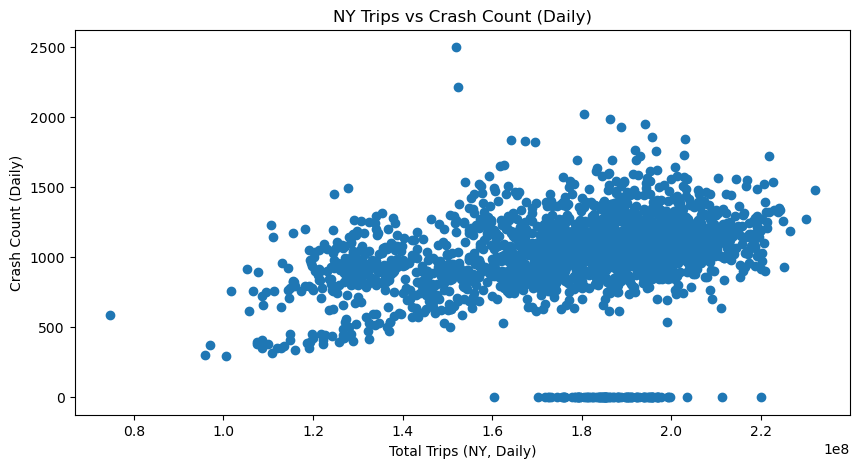

In [283]:
#now the scatterplot for the correlation
plt.figure()
plt.scatter(tc["trips_total"], tc["crash_count"])
plt.xlabel("Total Trips (NY, Daily)")
plt.ylabel("Crash Count (Daily)")
plt.title("NY Trips vs Crash Count (Daily)")
plt.show()

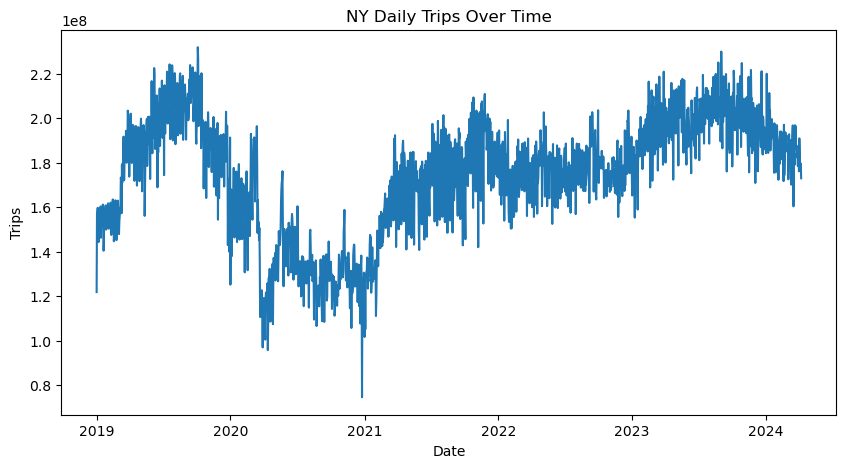

In [286]:
#plotting trips over time

tc_sorted = tc.sort_values("date_key")

plt.figure()
plt.plot(tc_sorted["date_key"], tc_sorted["trips_total"])
plt.xlabel("Date")
plt.ylabel("Trips")
plt.title("NY Daily Trips Over Time")
plt.show()


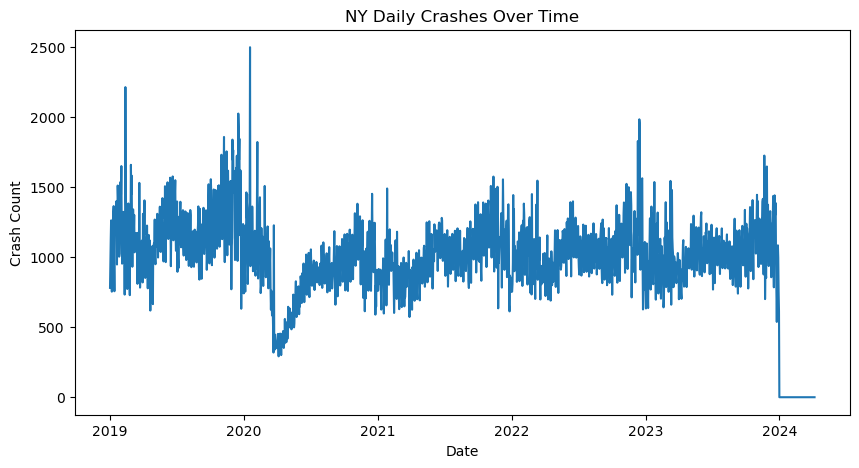

In [285]:
#plotting crashes over time

plt.figure()
plt.plot(tc_sorted["date_key"], tc_sorted["crash_count"])
plt.xlabel("Date")
plt.ylabel("Crash Count")
plt.title("NY Daily Crashes Over Time")
plt.show()

In [291]:
#creating & sorting by powerball day 
tp = trips_powerball_df.copy()
tp["date_key"] = pd.to_datetime(tp["date_key"])
tp["is_powerball_day"] = tp["powerball_draws"] > 0

#goruping by if it was a powerball day and inspecting the descriptives statasitcs 
tp.groupby("is_powerball_day")["trips_total"].describe()

,count,mean,std,min,25%,50%,75%,max
is_powerball_day,,,,,,,,
False,1240.0,2.507438e+09,3.793558e+08,1.048471e+09,2.281066e+09,2.580474e+09,2.785994e+09,3.281662e+09
True,683.0,2.582635e+09,3.338106e+08,1.614721e+09,2.420976e+09,2.624912e+09,2.831593e+09,3.232264e+09


C:\Users\angel\AppData\Local\Temp\ipykernel_28616\3774772181.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_draw_days, draw_days], labels=["No Draw", "Draw Day"])


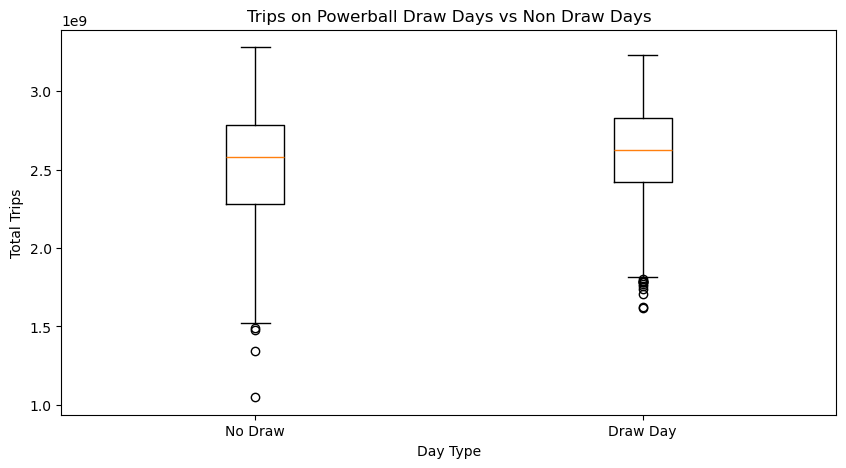

In [292]:
#plotting a box plot to compare a draw day vs a non
draw_days = tp[tp["is_powerball_day"]]["trips_total"]
non_draw_days = tp[~tp["is_powerball_day"]]["trips_total"]

plt.figure()
plt.boxplot([non_draw_days, draw_days], labels=["No Draw", "Draw Day"])
plt.xlabel("Day Type")
plt.ylabel("Total Trips")
plt.title("Trips on Powerball Draw Days vs Non Draw Days")
plt.show()

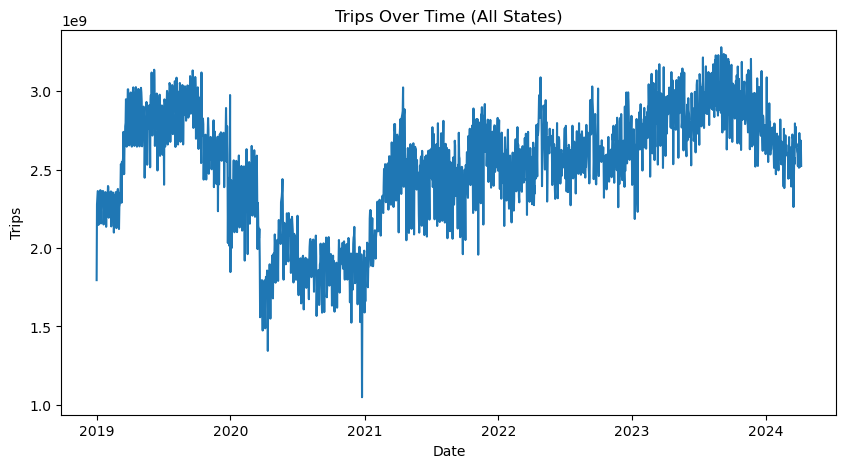

In [293]:
#plot to show the trips over all time over all states not just ny
tp_sorted = tp.sort_values("date_key")

plt.figure()
plt.plot(tp_sorted["date_key"], tp_sorted["trips_total"])
plt.xlabel("Date")
plt.ylabel("Trips")
plt.title("Trips Over Time (All States)")
plt.show()

In [299]:
#again stsatics on if it is a powerball day on dates of a crash rather than trips this time
cp = crash_powerball_df.copy()
cp["date_key"] = pd.to_datetime(cp["date_key"])
cp["is_powerball_day"] = cp["powerball_draws"] > 0

cp.groupby("is_powerball_day")["crash_count"].describe()

,count,mean,std,min,25%,50%,75%,max
is_powerball_day,,,,,,,,
False,1185.0,1049.192405,252.777694,292.0,893.0,1043.0,1199.0,2215.0
True,641.0,1037.544462,206.961836,339.0,928.0,1029.0,1146.0,2500.0


C:\Users\angel\AppData\Local\Temp\ipykernel_28616\2100274392.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_draw_crashes, draw_crashes], labels=["No Draw", "Draw Day"])


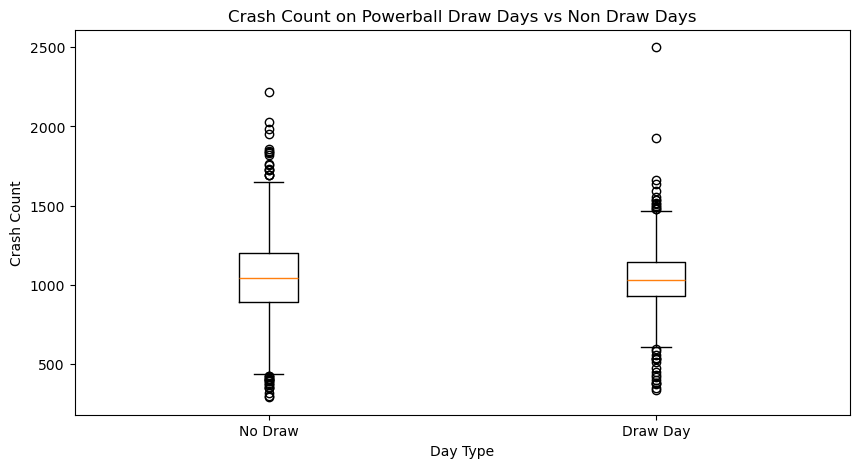

In [302]:
#plotting the box plot on crashes on non draw days and draw days
draw_crashes = cp[cp["is_powerball_day"]]["crash_count"]
non_draw_crashes = cp[~cp["is_powerball_day"]]["crash_count"]

plt.figure()
plt.boxplot([non_draw_crashes, draw_crashes], labels=["No Draw", "Draw Day"])
plt.xlabel("Day Type")
plt.ylabel("Crash Count")
plt.title("Crash Count on Powerball Draw Days vs Non Draw Days")
plt.show()

In [303]:
#now for the last dataframe, display a corrleation table since it's 3 variables
tcp = ny_trips_crash_powerball_df.copy()
tcp["date_key"] = pd.to_datetime(tcp["date_key"])

tcp[["trips_total", "crash_count", "powerball_draws"]].corr()

,trips_total,crash_count,powerball_draws
trips_total,1.000000,0.243225,0.080257
crash_count,0.243225,1.000000,0.098104
powerball_draws,0.080257,0.098104,1.000000


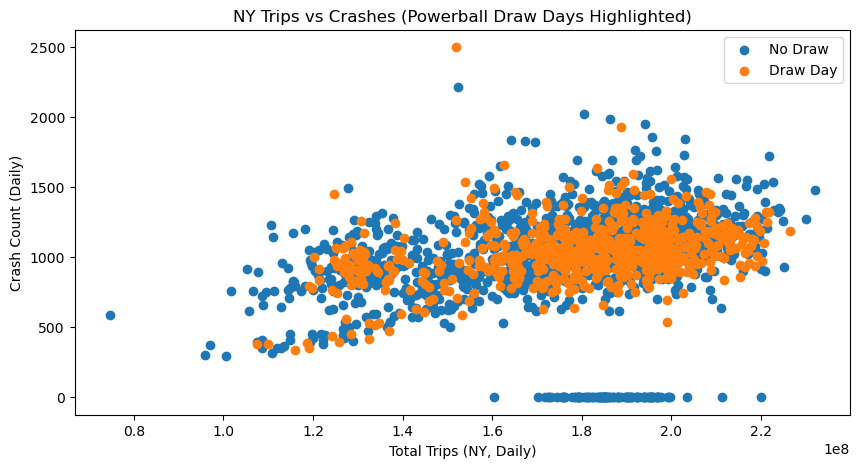

In [304]:
#plot scatterplot, by powerball day, trips vs crashes
tcp["is_powerball_day"] = tcp["powerball_draws"] > 0

plt.figure()
plt.scatter(
    tcp[~tcp["is_powerball_day"]]["trips_total"],
    tcp[~tcp["is_powerball_day"]]["crash_count"],
    label="No Draw"
)

plt.scatter(
    tcp[tcp["is_powerball_day"]]["trips_total"],
    tcp[tcp["is_powerball_day"]]["crash_count"],
    label="Draw Day"
)

plt.xlabel("Total Trips (NY, Daily)")
plt.ylabel("Crash Count (Daily)")
plt.title("NY Trips vs Crashes (Powerball Draw Days Highlighted)")
plt.legend()
plt.show()

It seems that in gerneal crash counts in NY are closely related to how much people travel, this pattern is bisible in both the scatter plot and the time ones. In comparision, Powerball doesn't really effect either of crash and travel since they look very simlar in comparsion on draw to non-draw days. When you compare all 3 variables together powerball doensn't have much impact on the other two variables. This implies that (reasonably) that travel rates have more impact on crash rates than powerball.

# 4. Model Building

o Based on your analysis, identify a specific question or hypothesis to test.

o Choose two appropriate machine learning algorithms for prediction or
classification tasks to compare. For example, you could consider a linear
regression model with and without regularization. Or you could implement
logistic regression with full features or with reduced features using LASSO or
PCA-reduced features.

o Split the dataset into training and testing sets and build your models using
cross-validation.

o Evaluate the performance of your models using suitable metrics. Discuss
why you chose these metrics and why they are appropriate for your problem.

The most intersting question I can think after looking at this dataframes is :
does having a larger powerball multiple effect daily travel or crash rate in NY?

Hypothesis: Days with a higher powerball multiplier may effect travel volume and crashes in NY. Larger multipliers may garner more interest and have more of an effect on the general population

I plan to use predcition models to see if crash is in any way related to powerball multiplier. comparing boht the models using training and testing data.

In [323]:
#creating a table that is sorted/grouped by the max multiplier
powerball_multiplier_daily = (
    powerball_df_clean
    .groupby("date_key")["Multiplier"]
    .max()
    .reset_index(name="multiplier")
)

In [324]:
#merge the multiplier into the previous df
ny_trips_crash_powerball_df = trips_crashes_ny.merge(
    powerball_multiplier_daily,
    on="date_key",
    how="left"
)

ny_trips_crash_powerball_df["multiplier"] = (
    ny_trips_crash_powerball_df["multiplier"].fillna(0)
)

In [325]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

df = ny_trips_crash_powerball_df.copy()

#assign the varialbes for the model

X_base = df[["trips_total"]]
X_extended = df[["trips_total", "multiplier"]]
y = df["crash_count"]

In [328]:
#dedcided to make it a 0.2 test size
Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

Xe_train, Xe_test, _, _ = train_test_split(
    X_extended, y, test_size=0.2, random_state=42
)

model_base = LinearRegression()
model_base.fit(Xb_train, y_train)
pred_base = model_base.predict(Xb_test)

model_ext = LinearRegression()
model_ext.fit(Xe_train, y_train)
pred_ext = model_ext.predict(Xe_test)

In [331]:
#created a datadf to make it more organized to show the results 
results = {
    "Model": ["Trips Only", "Trips + Multiplier"],
    "MSE": [
        mean_squared_error(y_test, pred_base),
        mean_squared_error(y_test, pred_ext)
    ],
    "R2": [
        r2_score(y_test, pred_base),
        r2_score(y_test, pred_ext)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,MSE,R2
0,Trips Only,108369.472995,0.046797
1,Trips + Multiplier,109966.835685,0.032746


It seems the means squared error is lessons when we add the powerball multiplier. Our r2 value also lessons when we add our powerball multiplier. This basically confirms that although trips and crash can predict each other a little, powerball multiplier doesn't imporve the prediction at all and in fact makes it worse.

In [334]:
#now we cross validate it with five folds, assinging cv to 5
cv_base = cross_val_score(
    LinearRegression(),
    X_base,
    y,
    cv=5,
    scoring="r2"
)

cv_ext = cross_val_score(
    LinearRegression(),
    X_extended,
    y,
    cv=5,
    scoring="r2"
)

cv_results = pd.DataFrame({
    "Model": ["Trips Only", "Trips + Multiplier"],
    "Mean CV R2": [np.mean(cv_base), np.mean(cv_ext)]
})

cv_results

,Model,Mean CV R2
0,Trips Only,-0.265784
1,Trips + Multiplier,-0.264913


The r2 values are negative and almost the same. It basically translates to the model perfomring worse because we the mutiplier doesn't really relate to the other two at all. 

Then again, some limitations to this model would be that we cherry picked a lot of varialbes for simplicity's sake and and we are missing a lot of varialbes from the original dataframe that would've revelaed more (like weather, day of the week, etc). Another thing to consider is that the multplier could've been more corrleated with trends over time rather than human behavior like we were trying to compare.

In conclusion, Travel volume and crashes in NY city have a reationship (but somewhat weak). However, lottery multipliers doesn't effect the general movement/accidents of the populance. 